# Image Visualization and RGB Channel Analysis in CIFAR-10 Dataset 

In [1]:
# Importing Libraries for Deep Learning and Visualization
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models


In [ ]:
# Loading CIFAR-10 Training and Testing Dataset

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 90s 1us/step


In [ ]:
# Creating List of Image Categories (OPTIONAL)

In [3]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


In [ ]:
# NORMALIZING TRAINING AND TEST IMAGES

In [4]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [5]:
print("Train Images Shape :", train_images.shape)
print("Test Images Shape  :", test_images.shape)

Train Images Shape : (50000, 32, 32, 3)
Test Images Shape  : (10000, 32, 32, 3)


In [ ]:
#  Displaying Multiple Training Images in a Grid (OPTIONAL)

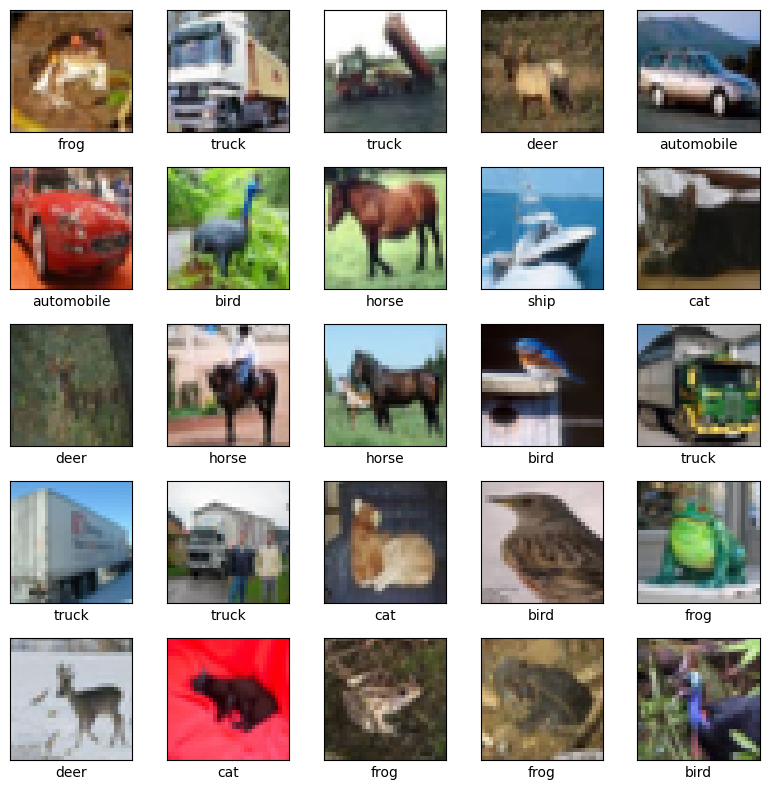

In [6]:
plt.figure(figsize=(8,8))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])

plt.tight_layout()
plt.show()


In [ ]:
# Displaying Original Image and RGB Color Channels (OPTIONAL)

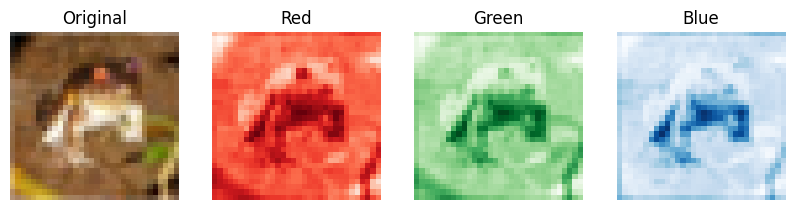

In [7]:
image = train_images[0]

R = image[:, :, 0]
G = image[:, :, 1]
B = image[:, :, 2]

fig, axs = plt.subplots(1, 4, figsize=(10,3))

axs[0].imshow(image)
axs[0].set_title("Original")

axs[1].imshow(R, cmap='Reds')
axs[1].set_title("Red")

axs[2].imshow(G, cmap='Greens')
axs[2].set_title("Green")

axs[3].imshow(B, cmap='Blues')
axs[3].set_title("Blue")

for ax in axs:
    ax.axis("off")

plt.show()

In [12]:
# Cell 8: Building the CNN Model Architecture (INSERTED)
s


model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Cell 9: Compiling the Model (INSERTED)
# ==============================================================================
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [15]:
# ==============================================================================
# Cell 10: Training the Model (INSERTED)
# ==============================================================================
epochs = 10
history = model.fit(
    train_images,
    train_labels,
    epochs=epochs,
    validation_data=(test_images, test_labels),
    )

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.4505 - loss: 1.5117 - val_accuracy: 0.5306 - val_loss: 1.2968
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5858 - loss: 1.1696 - val_accuracy: 0.5831 - val_loss: 1.1757
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6424 - loss: 1.0139 - val_accuracy: 0.6114 - val_loss: 1.1011
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6752 - loss: 0.9210 - val_accuracy: 0.6446 - val_loss: 1.0193
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7015 - loss: 0.8474 - val_accuracy: 0.6783 - val_loss: 0.9144
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7225 - loss: 0.7886 - val_accuracy: 0.6970 - val_loss: 0.8808
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7401 - loss: 0.7351 - val_accuracy: 0.7011 - val_loss: 0.8500
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7554 -

In [18]:
model.save("model.keras")